## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/kndvi/

Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)

Conversion: Development Seed (openEO-UDP project)


# Kernel NDVI

Kernel NDVI (kNDVI) is a recently proposed vegetation index ([Camps-Valls et al., 2021](https://www.science.org/doi/10.1126/sciadv.abc7447)) based on a nonlinear generalization of the Normalized Difference Vegetation Index (NDVI). Rather than a simple linear ratio of Red and Near-Infrared (NIR) reflectance, kNDVI applies a Radial Basis Function (RBF) kernel to re-scale that relationship into a more comples, second-order form:

$$kNDVI = \tanh\left(NDVI^2\right)$$

This formulation has been shown to correlate more strongly with field-measured biomass and crop yield, and to provide higher classification accuracy than standard NDVI in many contexts.

One important caveat: because kNDVI responds to the squared difference between Red and NIR, it can produce elevated values on non-vegetated surfaces such as water, ice, or cloud-covered areas. kNDVI is therefore highly suitable for tracking vegetation patterns and processes, but should not be used in isolation to separate vegetation from other land cover types.

This notebook addresses that limitation by integrating the Scene Classification Layer (SCL) from Sentinel-2 L2A (Sen2Cor) into the process. Non-vegetation pixels are detected and assigned distinct colors:
- Blue for water
- Grey for clouds
- Brown for cloud shadows
- Cyan for snow and ice
- Red for defective pixels
- Shades of green and yellow reflecting kNDVI intensity for vegetated areas

## Overview

This notebook produces two types of output. Choose before running in the `Config` section:
- Set `return_stats = 1` to export raw kNDVI values, a grayscale image suitable for analysis and statistics
- Set `return_stats = 0` to export a color-rendered visualization (continuous green color ramp with cloud/shadow overlay)

In this notebook, we will:
1. Connect to CDSE OpenEO backend service
2. Define an area of interest, the notebook set it to Čepić plain, Istria, Croatia
3. Load Sentinel-2-L2A imagery (bands B04, B08, SCL) for 10–12 May 2025
4. Compute Kernel NDVI 
5. Mask clouds, shadows, and water using the Scene Classification Layer (SCL), and colorize them using a cloud palette
7. Apply a vegetation color ramp to the kNDVI values
8. Download and visualize the result

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [3]:
import openeo
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from openeo.processes import tanh, power, if_, array_create, and_, not_, eq

## Connect to CDSE OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [24]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates for Čepić plain, Istria, Croatia.

In [25]:
spatial_extent = {"west": 14.09, "east": 14.27, "south": 45.174, "north": 45.25}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data.

In [26]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=["2025-05-10", "2025-05-12"], 
    bands=[
        "B04",
        "B08",
        "SCL"
    ],
)

s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

## Config

This notebook produces two types of output. Choose before running in the `Config` section:
- Set `return_stats = 1` to export raw kNDVI values, a grayscale image suitable for analysis and statistics
- Set `return_stats = 0` to export a color-rendered visualization (continuous green color ramp with cloud/shadow overlay)

In [ ]:
return_stats = 0

if return_stats:
    file_name = f"kndvi_stats.png"
else:
    file_name = f"kndvi_image.png"

kndvi_ramp = [
    (-1.1, [0, 0, 0]),
    (-0.2, [0.75, 0.75, 0.75]), 
    (-0.1, [0.86, 0.86, 0.86]), 
    (0, [1, 1, 0.88]), 
    (0.025, [1, 0.98, 0.8]), 
    (0.05, [0.93, 0.91, 0.71]),
    (0.075, [0.87, 0.85, 0.61]), 
    (0.1, [0.8, 0.78, 0.51]),
    (0.125, [0.74, 0.72, 0.42]), 
    (0.15, [0.69, 0.76, 0.38]),
    (0.175, [0.64, 0.8, 0.35]), 
    (0.2, [0.57, 0.75, 0.32]), 
    (0.25, [0.5, 0.7, 0.28]), 
    (0.3, [0.44, 0.64, 0.25]),
    (0.35, [0.38, 0.59, 0.21]),
    (0.4, [0.31, 0.54, 0.18]), 
    (0.45, [0.25, 0.49, 0.14]),
    (0.5, [0.19, 0.43, 0.11]),
    (0.55, [0.13, 0.38, 0.07]), 
    (0.6, [0.06, 0.33, 0.04]) 
]

cloud_palette = [
    (0, [0, 0, 0]), # No Data (Missing data) - black  
    (1, [1, 0, 0.016]), # Saturated or defective pixel - red 
    (2, [0.525, 0.525, 0.525]), # Topographic casted shadows - very dark grey
    (3, [0.467, 0.298, 0.043]), # Cloud shadows - dark brown
    (6, [0, 0, 1]), # Water (dark and bright) - blue
    (7, [0.506, 0.506, 0.506]), # Unclassified - dark grey
    (8, [0.753, 0.753, 0.753]), # Cloud medium probability - grey
    (9, [0.949, 0.949, 0.949]), # Cloud high probability - white
    (10, [0.733, 0.773, 0.925]), # Thin cirrus - very bright blue
    (11, [0.325, 1, 0.980]) # Snow or ice - very bright pink
]

base_color = array_create([0, 0.27, 0])

In [28]:
def kndvi_viz(data):
    B04, B08, SCL = data[0], data[1], data[2]

    B04 = B04 / 10000
    B08 = B08 / 10000

    ndvi = (B08 - B04) / (B08 + B04)
    kndvi = tanh(power(ndvi, 2))

    cloud_mask = and_((SCL != 4), (SCL != 5))
    kndvi_masked = if_(not_(cloud_mask), kndvi, None)
    
    rgb = base_color

    # Build RGB from kNDVI color ramp
    for threshold, color in reversed(kndvi_ramp):
        rgb = if_(kndvi_masked < threshold, array_create(color), rgb)
    
    # Override cloud/shadow/water pixels with their palette color
    for scl_class, color in reversed(cloud_palette):
        rgb = if_(eq(SCL, scl_class), array_create(color), rgb)

    if return_stats:
        return kndvi_masked
    else:
        return rgb

In [29]:
kndvi_image = s2cube.apply_dimension(
    dimension="bands",
    process=kndvi_viz
)

kndvi_image = kndvi_image.linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

In [31]:
# Send job to backend and download the result
kndvi_image.download(file_name)

## Visualize the Result

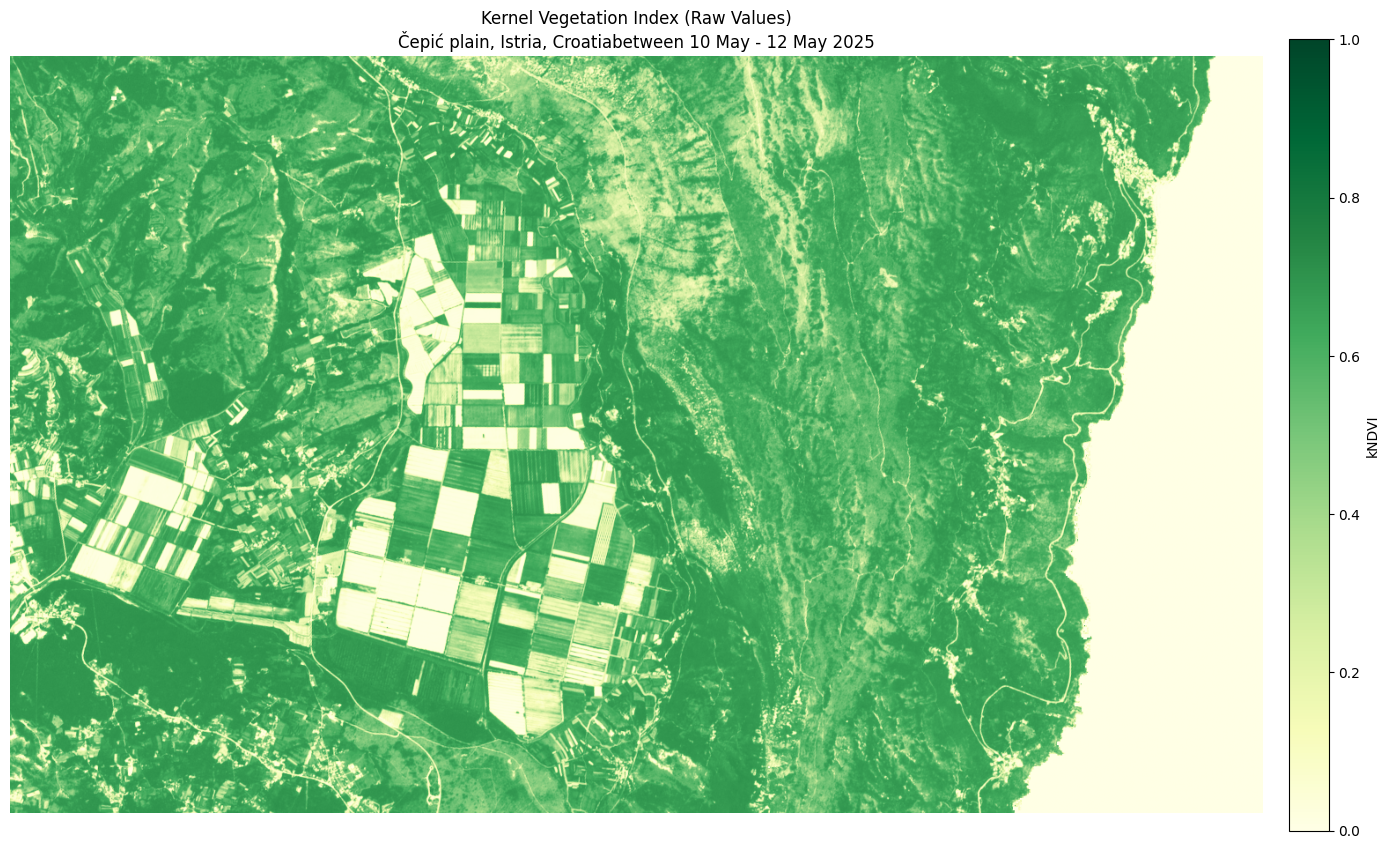

In [21]:
# Load and display the image
img = Image.open("kndvi_stats.png").convert("L")
arr = np.array(img) / 255.0

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
im = ax.imshow(arr, cmap="YlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="kNDVI", fraction=0.03, pad=0.02)
ax.set_title(
    "Kernel Vegetation Index (Raw Values)\n"
    "Čepić plain, Istria, Croatia"
    "between 10 May - 12 May 2025",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

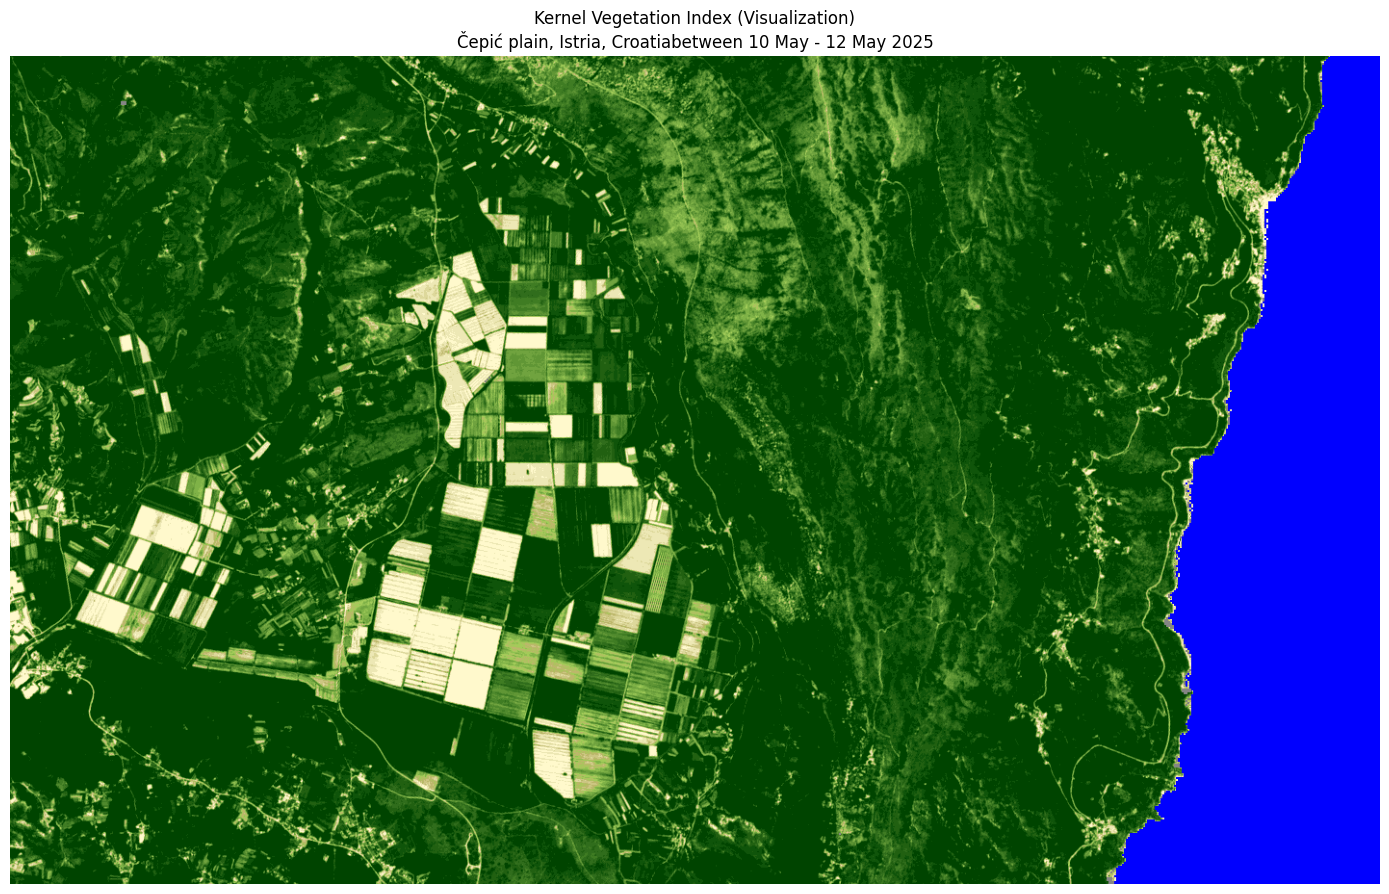

In [4]:
# Load and display the image
img = Image.open("kndvi_image.png")

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ax.imshow(img)
ax.set_title(
    "Kernel Vegetation Index (Visualization)\n"
    "Čepić plain, Istria, Croatia"
    "between 10 May - 12 May 2025",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation Guide

### kNDVI Value Guide
| Color Gradient | kNDVI Range | Interpretation |
|-------|-------------------|----------------------|
| Grey | < 0 | Bare soil / non-vegetated |
| Tan/Beige | 0 - 0.1 | Sparse vegetation |
| Yellow to Green | 0.1 - 0.3 | Moderate vegetation |
| Dark Green | 0.3 - 0.6 | Dense vegetation |
| Fixed Dark Green | > 0.6 | Very dense vegetation |

- Standard NDVI tends to saturate in areas of dense vegetation, compressing the differences between moderately and highly vegetated pixels
- kNDVI reduces this saturation effect, which means it retains more detail at the lower-to-moderate end of the vegetation spectrum, making it better for distinguishing fine-scale differences in sparse or developing vegetation such as early-season crops

### Applications:
- Monitoring crop health and growth stages throughout agricultural season
- Detecting early signs of vegetation stress before they become visible to the naked eye
- Mapping vegetation density gradients across forests, grasslands, or wetlands
- Tracking seasonal and inter-annual changes in vegetation greenness

### Limitations
- kNDVI can produce elevated values on non-vegetated surfaces such as water, bare soil, built-up areas, so it should not be used alone to separate vegetation from other land cover areas
- Results depend on the quality of the SCL cloud mask. Undetected thin clouds, haze, and shadow can introduce noise in the output
- Image from a single time selection may not represent vegetation greenness, as seasonal phenology and short-term weather events can influence such result

## Citation
Camps-Valls, G., et. al. (2021). *A Unified Vegetation Index for Quantifying the Terrestrial Biosphere*. **Science Advances**, 7(9). DOI: 10.1126/sciadv.abc7447

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Kernel NDVI](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/kndvi/)

**Author:**  András Zlinszky, @azlinszky

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.